# Day 5 — Data Visualisation: Matplotlib & Seaborn
**Date:** 25 March 2026 | **Phase 1 — Week 1** | **Roadmap: DS-AI-75D**

> Mastering data visualisation — 6+ chart types on real Titanic data.
> Every chart tells a story. Learn to tell it clearly.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Load local Titanic CSV
df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")

# Set style for all plots
plt.style.use("dark_background")
sns.set_palette("husl")

print(f"Pandas:     {pd.__version__}")
print(f"Matplotlib: {mpl.__version__}")
print(f"Seaborn:    {sns.__version__}")
print(f"Dataset:    {df.shape}")
print("Ready!")

Pandas:     3.0.1
Matplotlib: 3.10.8
Seaborn:    0.13.2
Dataset:    (891, 12)
Ready!


## 2. Matplotlib Fundamentals — Anatomy of a Figure

### 2.1 Figure & Axes — The Building Blocks

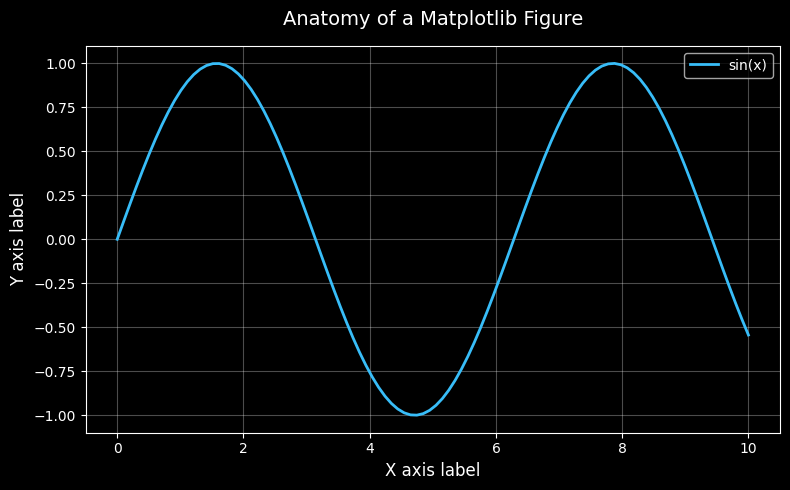

Figure rendered!


In [2]:
# Every Matplotlib plot has:
# Figure — the whole canvas
# Axes   — the actual plot area (can have multiple per figure)

fig, ax = plt.subplots(figsize=(8, 5))

# Simple line plot to understand the anatomy
x = np.linspace(0, 10, 100)
y = np.sin(x)

ax.plot(x, y, color="#38bdf8", linewidth=2, label="sin(x)")
ax.set_title("Anatomy of a Matplotlib Figure", fontsize=14, pad=15)
ax.set_xlabel("X axis label", fontsize=12)
ax.set_ylabel("Y axis label", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Figure rendered!")

### 2.2 Bar Chart — Survival Count by Class

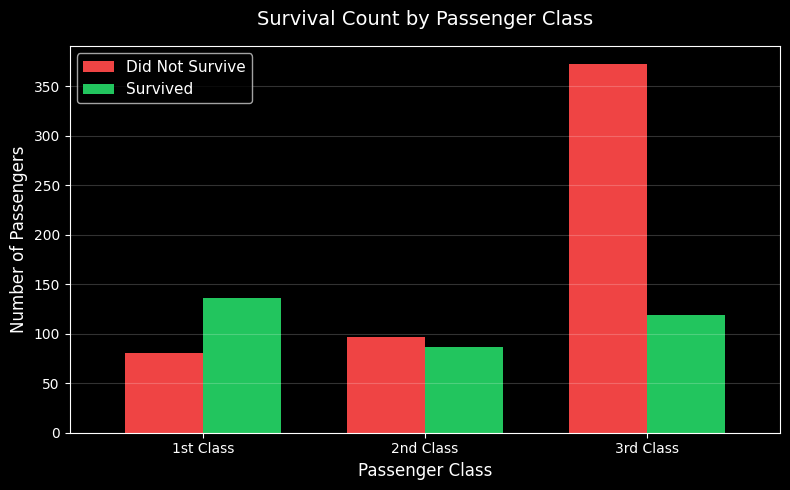

Bar chart done!


In [3]:
# Bar chart — comparing categories
fig, ax = plt.subplots(figsize=(8, 5))

# Count survivors and non-survivors per class
survival_counts = df.groupby(["Pclass", "Survived"]).size().unstack()
survival_counts.columns = ["Did Not Survive", "Survived"]

survival_counts.plot(
    kind="bar", ax=ax, color=["#ef4444", "#22c55e"], edgecolor="none", width=0.7
)

ax.set_title("Survival Count by Passenger Class", fontsize=14, pad=15)
ax.set_xlabel("Passenger Class", fontsize=12)
ax.set_ylabel("Number of Passengers", fontsize=12)
ax.set_xticklabels(["1st Class", "2nd Class", "3rd Class"], rotation=0)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.show()
print("Bar chart done!")

### 2.3 Histogram — Age Distribution

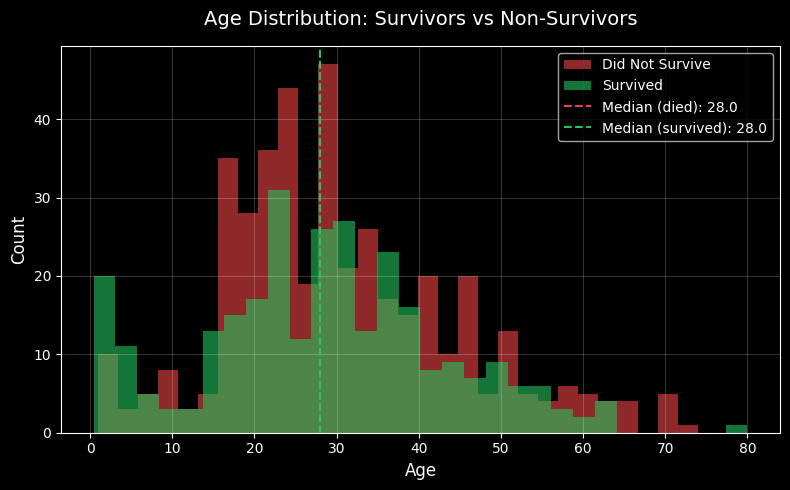

Histogram done!


In [4]:
# Histogram — distribution of a continuous variable
fig, ax = plt.subplots(figsize=(8, 5))

# Separate survivors and non-survivors
survived = df[df["Survived"] == 1]["Age"].dropna()
died = df[df["Survived"] == 0]["Age"].dropna()

ax.hist(
    died, bins=30, alpha=0.6, color="#ef4444", label="Did Not Survive", edgecolor="none"
)
ax.hist(
    survived, bins=30, alpha=0.6, color="#22c55e", label="Survived", edgecolor="none"
)

ax.axvline(
    died.median(),
    color="#ef4444",
    linestyle="--",
    linewidth=1.5,
    label=f"Median (died): {died.median():.1f}",
)
ax.axvline(
    survived.median(),
    color="#22c55e",
    linestyle="--",
    linewidth=1.5,
    label=f"Median (survived): {survived.median():.1f}",
)

ax.set_title("Age Distribution: Survivors vs Non-Survivors", fontsize=14, pad=15)
ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
print("Histogram done!")

### 2.4 Scatter Plot — Age vs Fare

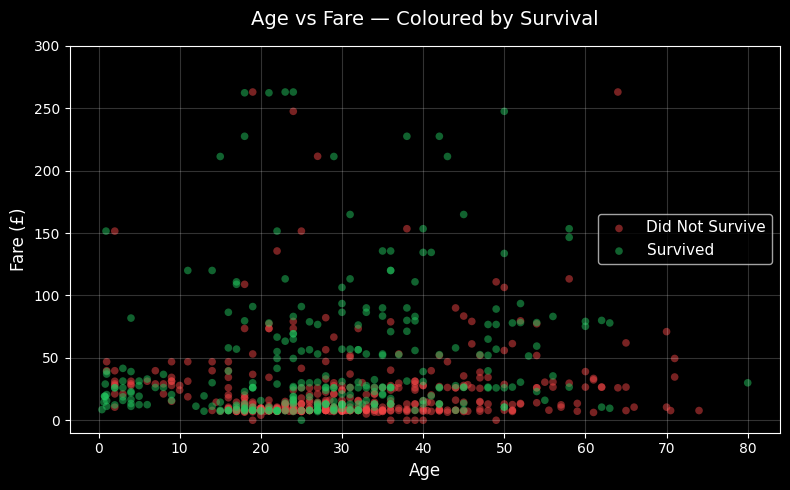

Scatter plot done!


In [5]:
# Scatter plot — relationship between two continuous variables
fig, ax = plt.subplots(figsize=(8, 5))

# Plot survivors and non-survivors separately
for survived, color, label in [
    (0, "#ef4444", "Did Not Survive"),
    (1, "#22c55e", "Survived"),
]:
    subset = df[df["Survived"] == survived]
    ax.scatter(
        subset["Age"],
        subset["Fare"],
        c=color,
        alpha=0.5,
        s=30,
        label=label,
        edgecolors="none",
    )

ax.set_title("Age vs Fare — Coloured by Survival", fontsize=14, pad=15)
ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("Fare (£)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
ax.set_ylim(-10, 300)  # Remove extreme outliers visually

plt.tight_layout()
plt.show()
print("Scatter plot done!")

### 2.5 Subplots — Multiple Charts in One Figure

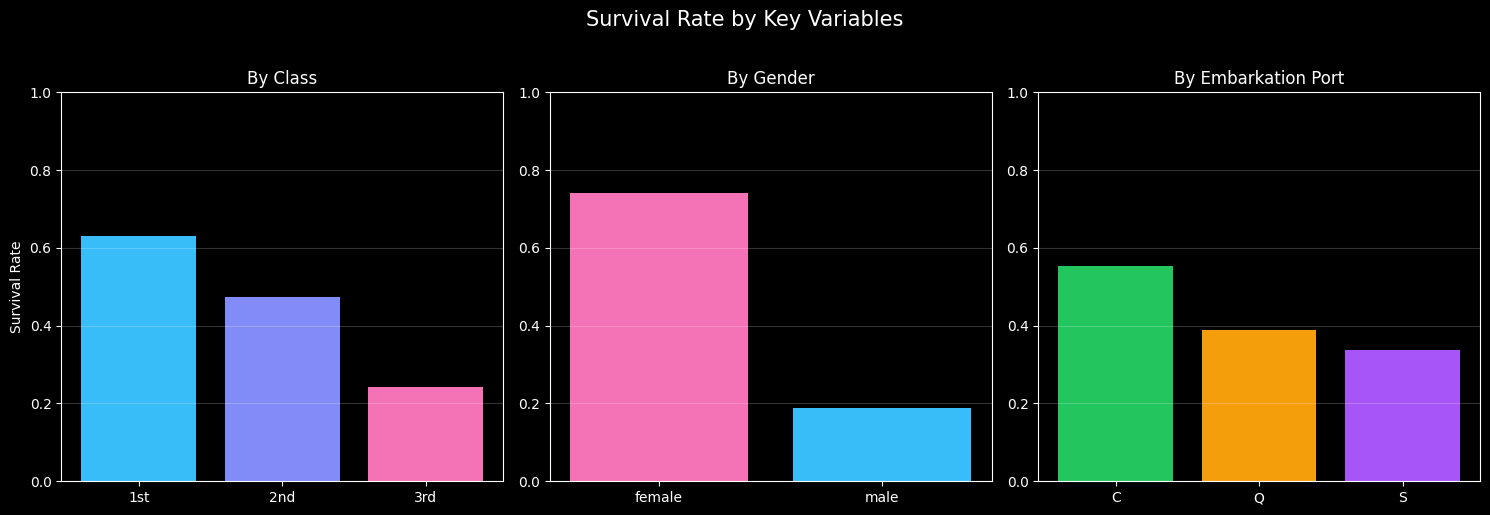

Subplots done!


In [6]:
# Subplots — show multiple charts together
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Survival Rate by Key Variables", fontsize=15, y=1.02)

# Chart 1 — by Class
class_survival = df.groupby("Pclass")["Survived"].mean()
axes[0].bar(
    ["1st", "2nd", "3rd"],
    class_survival.values,
    color=["#38bdf8", "#818cf8", "#f472b6"],
)
axes[0].set_title("By Class", fontsize=12)
axes[0].set_ylabel("Survival Rate")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.2, axis="y")

# Chart 2 — by Sex
sex_survival = df.groupby("Sex")["Survived"].mean()
axes[1].bar(sex_survival.index, sex_survival.values, color=["#f472b6", "#38bdf8"])
axes[1].set_title("By Gender", fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.2, axis="y")

# Chart 3 — by Embarked
emb_survival = df.groupby("Embarked")["Survived"].mean()
axes[2].bar(
    emb_survival.index, emb_survival.values, color=["#22c55e", "#f59e0b", "#a855f7"]
)
axes[2].set_title("By Embarkation Port", fontsize=12)
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.show()
print("Subplots done!")

## 3. Seaborn — Statistical Visualisation
Seaborn builds on Matplotlib with beautiful statistical charts in fewer lines of code.

### 3.1 Heatmap — Correlation Matrix

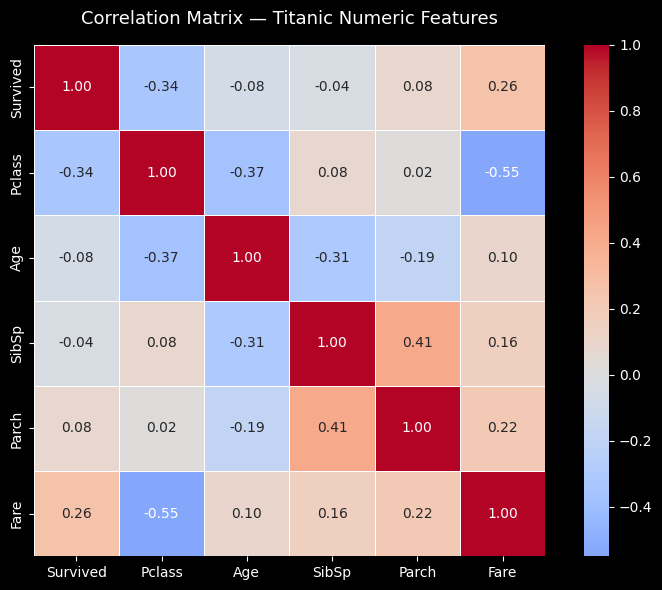

Heatmap done!


In [7]:
# Heatmap — show correlations between all numeric columns
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate correlation matrix
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,  # Show numbers in cells
    fmt=".2f",  # 2 decimal places
    cmap="coolwarm",  # Blue=negative, Red=positive
    center=0,  # Centre colourscale at 0
    ax=ax,
    linewidths=0.5,
    square=True,
)

ax.set_title("Correlation Matrix — Titanic Numeric Features", fontsize=13, pad=15)

plt.tight_layout()
plt.show()
print("Heatmap done!")

### 3.2 Boxplot — Fare Distribution by Class

C:\Users\vijen\AppData\Local\Temp\ipykernel_13300\809126562.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\vijen\AppData\Local\Temp\ipykernel_13300\809126562.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["1st Class", "2nd Class", "3rd Class"])


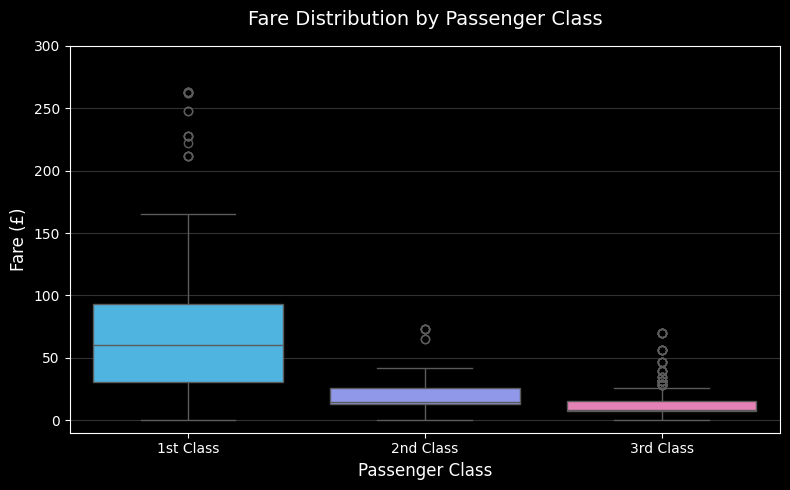

Boxplot done!


In [8]:
# Boxplot — shows median, quartiles, and outliers
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df, x="Pclass", y="Fare", palette=["#38bdf8", "#818cf8", "#f472b6"], ax=ax
)

ax.set_title("Fare Distribution by Passenger Class", fontsize=14, pad=15)
ax.set_xlabel("Passenger Class", fontsize=12)
ax.set_ylabel("Fare (£)", fontsize=12)
ax.set_xticklabels(["1st Class", "2nd Class", "3rd Class"])
ax.set_ylim(-10, 300)
ax.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.show()
print("Boxplot done!")

### 3.3 Violin Plot — Age Distribution by Class and Sex

C:\Users\vijen\AppData\Local\Temp\ipykernel_13300\3009394027.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["1st Class", "2nd Class", "3rd Class"])


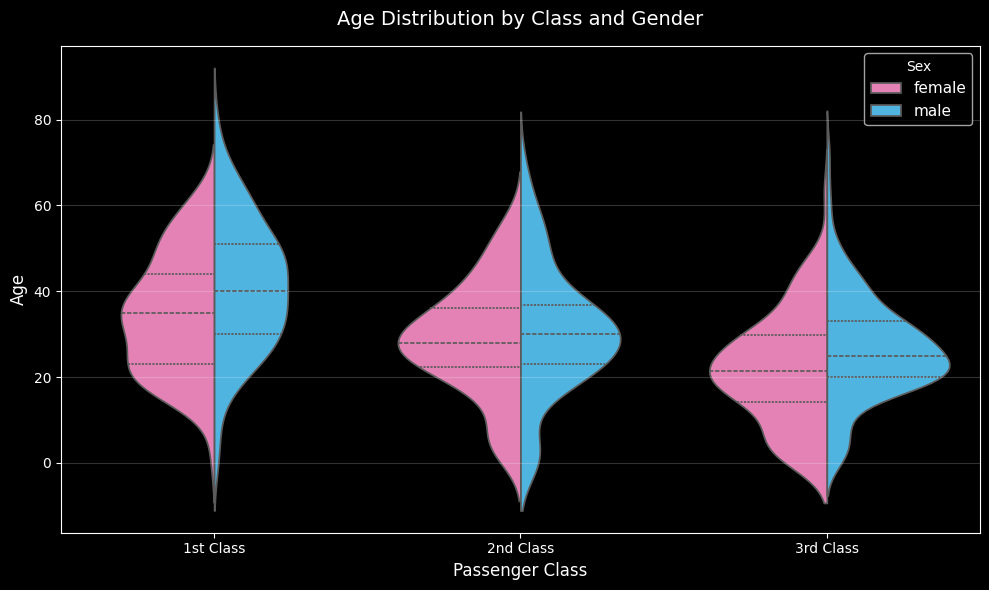

Violin plot done!


In [9]:
# Violin plot — like boxplot but shows full distribution shape
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Pclass",
    y="Age",
    hue="Sex",
    split=True,  # Split violin by hue
    palette=["#f472b6", "#38bdf8"],
    ax=ax,
    inner="quart",  # Show quartile lines inside
)

ax.set_title("Age Distribution by Class and Gender", fontsize=14, pad=15)
ax.set_xlabel("Passenger Class", fontsize=12)
ax.set_ylabel("Age", fontsize=12)
ax.set_xticklabels(["1st Class", "2nd Class", "3rd Class"])
ax.legend(title="Sex", fontsize=11)
ax.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.show()
print("Violin plot done!")

### 3.4 Count Plot — Passenger Count by Class and Survival

C:\Users\vijen\AppData\Local\Temp\ipykernel_13300\3814535116.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["1st Class", "2nd Class", "3rd Class"])


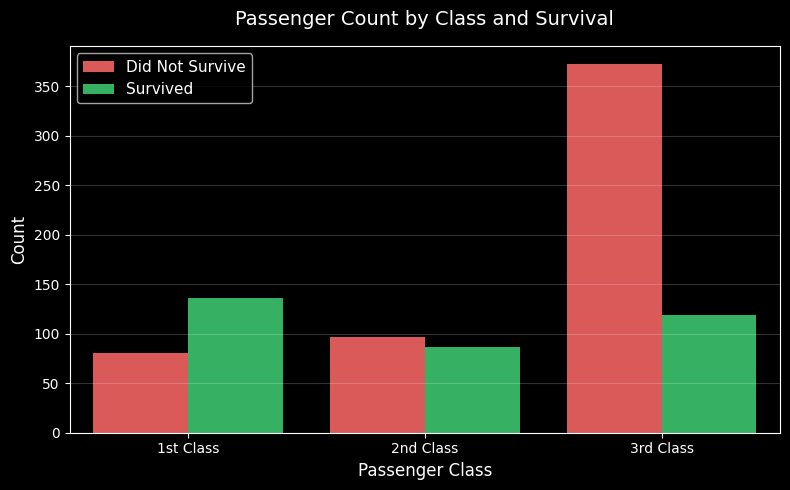

Count plot done!


In [10]:
# Count plot — counts of categorical variables
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=df, x="Pclass", hue="Survived", palette={0: "#ef4444", 1: "#22c55e"}, ax=ax
)

ax.set_title("Passenger Count by Class and Survival", fontsize=14, pad=15)
ax.set_xlabel("Passenger Class", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_xticklabels(["1st Class", "2nd Class", "3rd Class"])
ax.legend(["Did Not Survive", "Survived"], fontsize=11)
ax.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.show()
print("Count plot done!")

### 3.5 FacetGrid — Survival by Age Across Classes

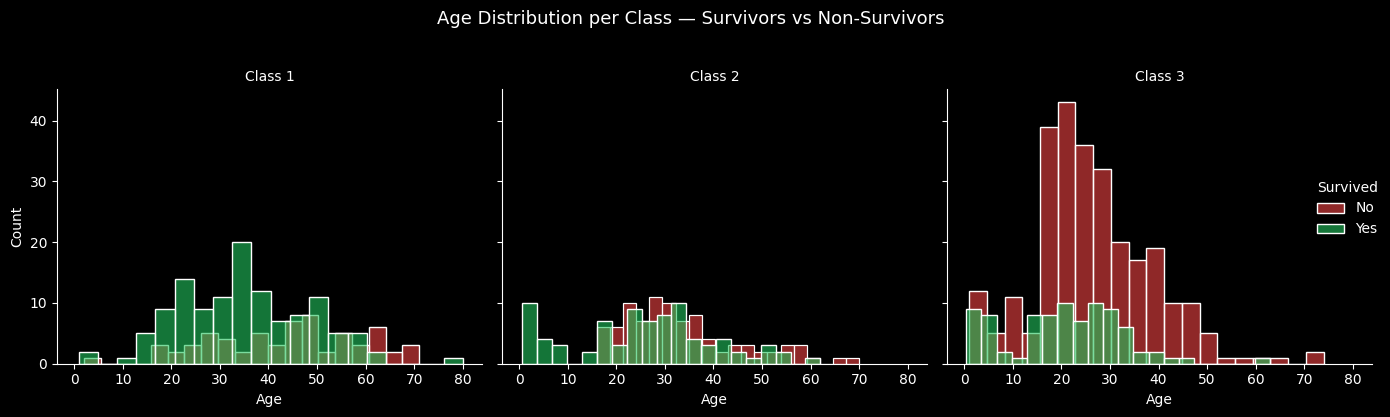

FacetGrid done!


In [11]:
# FacetGrid — same chart repeated across subgroups
g = sns.FacetGrid(
    df.dropna(subset=["Age"]),
    col="Pclass",
    hue="Survived",
    palette={0: "#ef4444", 1: "#22c55e"},
    height=4,
    aspect=1.1,
)

g.map(sns.histplot, "Age", bins=20, alpha=0.6)
g.add_legend(title="Survived", labels=["No", "Yes"])
g.set_titles("Class {col_name}")
g.set_axis_labels("Age", "Count")
g.figure.suptitle(
    "Age Distribution per Class — Survivors vs Non-Survivors", fontsize=13, y=1.03
)

plt.tight_layout()
plt.show()
print("FacetGrid done!")

## 4. Key Insights from Visualisations

1. **Bar chart:** 3rd class had far more deaths (372) than survivors (119)
2. **Histogram:** Survivors were slightly younger — median age 28 vs 30
3. **Scatter plot:** High fare passengers (1st class) clustered among survivors
4. **Heatmap:** Pclass and Fare are strongly negatively correlated (-0.55) — higher class = lower class number = higher fare
5. **Boxplot:** 1st class fare had extreme outliers (£500+) vs 3rd class median of £8
6. **Violin plot:** Age distributions similar across classes — class privilege not age determined survival
7. **FacetGrid:** Children visible in all classes — "women and children first" clearly visible in survival patterns
